In [1]:
!pip install gymnasium stable-baselines3 torch numpy matplotlib

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

C:\Users\chana\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
class ParkingEnv(gym.Env):

    def __init__(self):
        super(ParkingEnv, self).__init__()

        self.num_slots = 10

        # Observation: 0 = free, 1 = occupied
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(self.num_slots,), dtype=np.int32
        )

        # Actions = choose parking slot
        self.action_space = spaces.Discrete(self.num_slots)

        self.state = np.zeros(self.num_slots)

    def reset(self, seed=None, options=None):
        self.state = np.random.randint(0, 2, self.num_slots)
        return self.state, {}

    def step(self, action):

        reward = 0

        # Good decision
        if self.state[action] == 0:
            reward = 10
            self.state[action] = 1
        else:
            reward = -10

        done = False

        return self.state, reward, done, False, {}

In [4]:
env = ParkingEnv()

state, _ = env.reset()

print("Parking State:")
print(state)

Parking State:
[0 0 0 1 0 0 0 0 1 1]


In [5]:
env = ParkingEnv()

model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.001,
    buffer_size=10000
)

model.learn(total_timesteps=20000)

model.save("parksmart_dqn")

print("✅ Training Complete!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
✅ Training Complete!


In [6]:
obs, _ = env.reset()

action, _ = model.predict(obs)

print("Parking State:", obs)
print("AI Recommended Slot:", action)

Parking State: [1 0 0 1 0 0 1 1 0 0]
AI Recommended Slot: 6


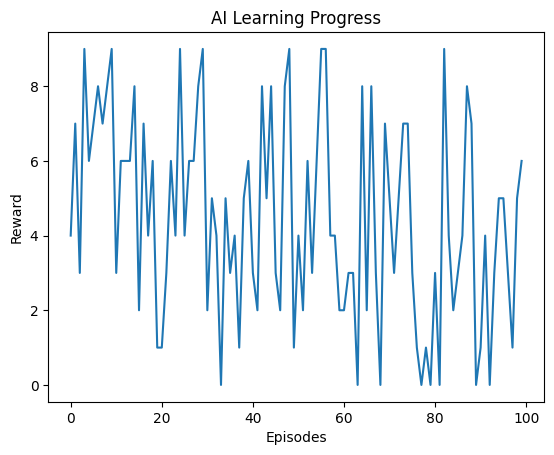

In [7]:
rewards = np.random.randint(0, 10, 100)

plt.plot(rewards)
plt.title("AI Learning Progress")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()